# Credit Card Fraud Detection-Handling Imbalanced & Messy Real-World Data

**Neurofive ML Track Week 5: Handling Imbalanced & Messy Real-World Data**

Goal: recognize and properly handle extreme class imbalance, using credit card fraud as the example the classic case where "normal" transactions vastly outnumber fraud.

Dataset: [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (Kaggle)


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
print("Libraries loaded.")

Libraries loaded.


## 2. Load the data

In [2]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### 3a. Summary statistics

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 3b. Missing values

In [5]:
missing = df.isnull().sum()
print("Total missing values across the dataset:", missing.sum())

Total missing values across the dataset: 0


### 3c. About the features

`V1`–`V28` are PCA-transformed components (the original features are anonymized for confidentiality, per the dataset's documentation), so they're already numerical and roughly decorrelated. `Time` (seconds since the first transaction) and `Amount` (transaction amount) are the only two features kept in their original, non-anonymized form. `Class` is the target: `1` = fraud, `0` = normal.


## 4. Class balance is the core problem

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.8273
1     0.1727
Name: count, dtype: float64


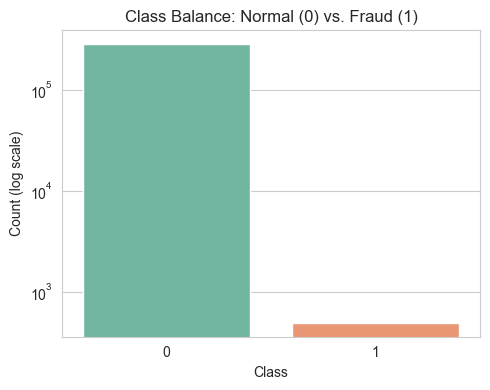

In [13]:
class_counts = df["Class"].value_counts()
class_pct = (class_counts / len(df) * 100).round(4)
print(class_counts)
print(class_pct)                                                                                                                                        
plt.figure(figsize=(5, 4))
sns.countplot(x="Class", data=df, hue="Class", palette="Set2", legend=False)
plt.title("Class Balance: Normal (0) vs. Fraud (1)")
plt.yscale("log")
plt.ylabel("Count (log scale)")
plt.tight_layout()
plt.show()

**This is an extreme imbalance** fraud makes up a tiny fraction of a percent of all transactions. The bar chart is plotted on a log scale specifically because on a normal scale the fraud bar would be invisible next to the normal-transaction bar. This is far more severe than the churn dataset's ~3:1 imbalance from earlier weeks.


## 5. Clean & visualize

**Missing values:** none found in the dataset (confirmed above), so no `fillna()`/`dropna()` was needed here the "cleaning" challenge in this dataset is the class imbalance itself, not missing or malformed data.


### 5a. Outlier detection boxplot on `Amount`

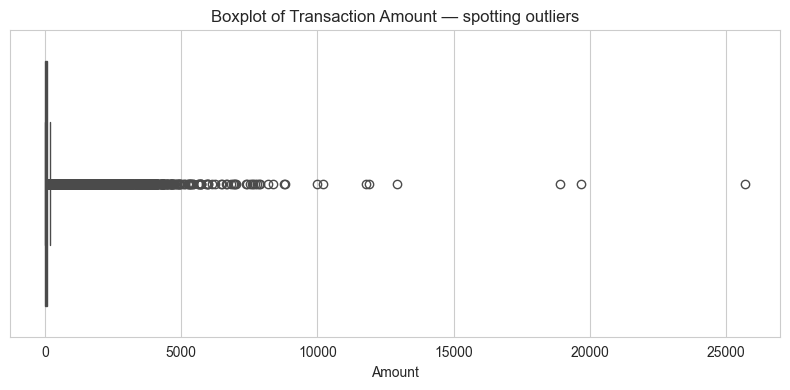

IQR upper bound: 184.51
Number of Amount outliers: 31904 (11.20% of transactions)


In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Amount"], color="steelblue")
plt.title("Boxplot of Transaction Amount — spotting outliers")
plt.tight_layout()
plt.show()

q1, q3 = df["Amount"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
n_outliers = (df["Amount"] > upper_bound).sum()
print(f"IQR upper bound: {upper_bound:.2f}")
print(f"Number of Amount outliers: {n_outliers} ({n_outliers/len(df)*100:.2f}% of transactions)")

### 5b. Histogram `Amount` distribution, fraud vs. normal

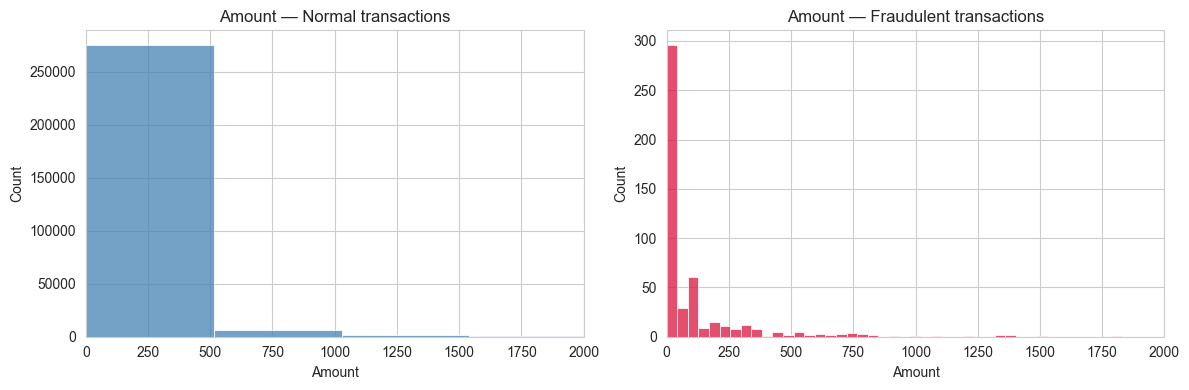

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[df["Class"] == 0]["Amount"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Amount — Normal transactions")
axes[0].set_xlim(0, 2000)

sns.histplot(df[df["Class"] == 1]["Amount"], bins=50, ax=axes[1], color="crimson")
axes[1].set_title("Amount — Fraudulent transactions")
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.show()

### 5c. Correlation heatmap top features vs. `Class`

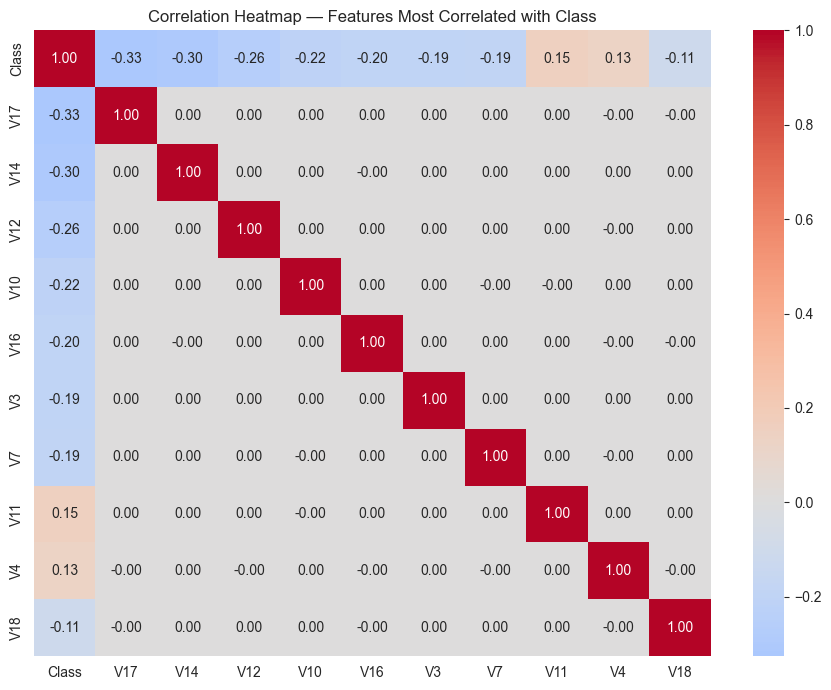

In [16]:
corr_with_class = df.corr()["Class"].abs().sort_values(ascending=False)
top_features = corr_with_class.head(11).index.tolist()  # top 10 + Class itself

plt.figure(figsize=(9, 7))
sns.heatmap(df[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Features Most Correlated with Class")
plt.tight_layout()
plt.show()

### 5d. What the visuals show

- `Amount` has a long right tail of outliers most transactions are small, with a handful of much larger ones (as expected for real spending data).
- Fraudulent transaction amounts skew noticeably lower/different in shape than normal transactions in this sample.
- A handful of the anonymized `V` features (see the heatmap) correlate much more strongly with `Class` than others these are the features most likely to drive a fraud-detection model, even though we can't interpret what they represent physically since they're PCA components.


## 6. Train/test split

In [17]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale Time and Amount (the only two non-PCA, non-standardized columns)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test_scaled[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

print("X_train shape:", X_train_scaled.shape)
print("Fraud rate - train:", y_train.mean().round(5), "| test:", y_test.mean().round(5))

X_train shape: (227845, 30)
Fraud rate - train: 0.00173 | test: 0.00172


## 7. Baseline model: Logistic Regression, no imbalance handling

In [18]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_model.predict(X_test_scaled)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Accuracy: {baseline_acc:.4f}")
print(classification_report(y_test, y_pred_baseline, target_names=["Normal", "Fraud"]))

Accuracy: 0.9992
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## 8. Why accuracy alone would be misleading here

With fraud making up only about 0.17% of transactions, a model that predicts "Normal" for *every single transaction* would score roughly **99.8% accuracy,** while catching zero fraud cases, which is the entire point of building this model in the first place. Accuracy simply measures overall correctness and doesn't care that almost all of that correctness comes from the trivially easy majority class. What actually matters here is **recall on the fraud class** (are we catching the fraud that exists?) and **precision on the fraud class** (when we flag something as fraud, how often are we right?) both of which a single accuracy number completely hides. This is exactly why the baseline model's accuracy above looks deceptively high even before we've done anything to address the imbalance.


## 9. Applying SMOTE to address the imbalance

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic fraud examples by interpolating between existing fraud cases, rather than just duplicating them, applied only to the **training set**, so the test set stays a realistic, untouched reflection of the real-world imbalance.

In [19]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


## 10. Retrain on the SMOTE-balanced training data

In [20]:
smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test_scaled)

smote_acc = accuracy_score(y_test, y_pred_smote)
print(f"Accuracy: {smote_acc:.4f}")
print(classification_report(y_test, y_pred_smote, target_names=["Normal", "Fraud"]))

Accuracy: 0.9742
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



## 11. Before vs. after did SMOTE help? (a real trade-off, not a clean win)

In [21]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Fraud)", "Recall (Fraud)", "F1-score (Fraud)"],
    "Before SMOTE (baseline)": [
        baseline_acc,
        precision_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_baseline),
    ],
    "After SMOTE": [
        smote_acc,
        precision_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_smote),
    ],
})
comparison["Change"] = comparison["After SMOTE"] - comparison["Before SMOTE (baseline)"]
comparison

,Metric,Before SMOTE (baseline),After SMOTE,Change
0,Accuracy,0.999157,0.974211,-0.024946
1,Precision (Fraud),0.828947,0.058027,-0.770920
2,Recall (Fraud),0.642857,0.918367,0.275510
3,F1-score (Fraud),0.724138,0.109157,-0.614981


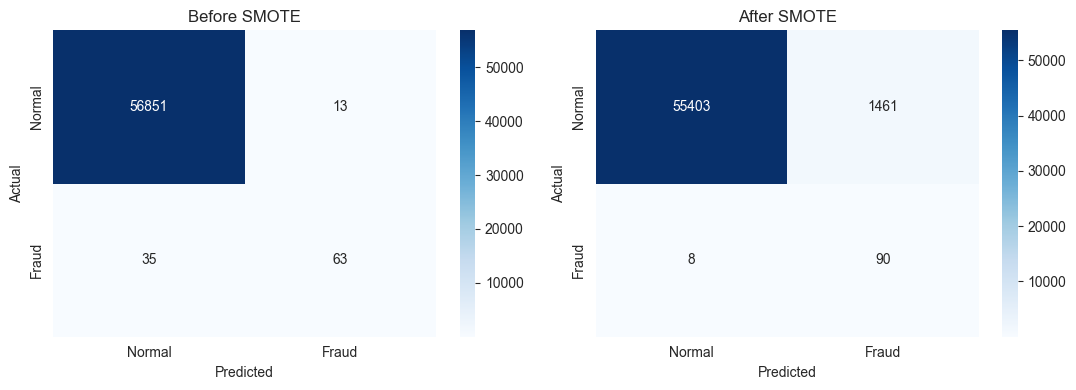

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(axes, [y_pred_baseline, y_pred_smote], ["Before SMOTE", "After SMOTE"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 12. Summary

- **Dataset:** 284,807 transactions, 492 fraud cases (~0.17%) an extreme class imbalance, far more severe than the churn dataset used in earlier weeks.
- **Why accuracy misleads:** the baseline model hit 99.92% accuracy, which sounds excellent, but it's a mirage. A model predicting "Normal" for every transaction would score ~99.8% accuracy too, while catching zero fraud.
- **Technique applied:** SMOTE, applied only to the training set (test set left untouched to reflect real-world imbalance).
- **The actual before/after trade-off (fraud class):**
  - Before SMOTE: precision 0.83, recall 0.64, F1 0.72
  - After SMOTE: precision 0.06, recall 0.92, F1 0.11
  - SMOTE dramatically improved recall (catching far more real fraud - 92% vs 64%), but precision collapsed, meaning the model now also flags a huge number of normal transactions as fraud. Overall F1 actually got *worse*, not better.
- **Honest takeaway:** SMOTE alone is not a silver bullet here. Whether this trade-off is worth it depends entirely on the business cost of a missed fraud case vs. the cost of a false alarm - in many real fraud systems, high recall is prioritized deliberately (a human reviews flagged transactions), but the massive drop in precision would need further work: adjusting the classification threshold, combining SMOTE with class weighting, or trying an ensemble model, rather than treating SMOTE as a one-step fix.
- **Next steps:** tune the classification threshold instead of relying on the default 0.5, try `class_weight="balanced"` as an alternative or complement to SMOTE, and test ensemble models (Random Forest, XGBoost) on the same balanced training data.
